In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.style.use("default")

In [53]:
df=pd.read_csv("googleplaystore.csv")

In [54]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [55]:
df.shape

(10841, 13)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [58]:
df.isnull().sum().sort_values(ascending=False)

Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
Size                 0
Reviews              0
Category             0
App                  0
Price                0
Installs             0
Last Updated         0
Genres               0
dtype: int64

In [61]:
df["Rating"]=pd.to_numeric(df["Rating"],errors="coerce")

In [62]:
df=df[df["Rating"]<=5]

In [63]:
df["Rating"]=df["Rating"].fillna(df["Rating"].median())

In [64]:
df.loc[df["Type"].isnull(),"Type"]="Free"

In [65]:
df["Content Rating"] = df["Content Rating"].fillna(
    df["Content Rating"].mode()[0]
)
df["Current Ver"] = df["Current Ver"].fillna("Unknown")
df["Android Ver"] = df["Android Ver"].fillna("Varies with device")


In [66]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [67]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")


In [68]:
df["Reviews"].dtype

dtype('int64')

In [69]:
df["Reviews"].isna().sum()

np.int64(0)

In [70]:
df["Installs"]=(
    df["Installs"]
    .astype(str)
    .str.replace(",","")
    .str.replace("+","",regex=False)
)
df["Installs"]=pd.to_numeric(df["Installs"],errors="coerce")

In [71]:
df["Installs"] = df["Installs"].fillna(df["Installs"].median())


In [73]:
df["Installs"].nunique()



19

In [74]:
df["Installs"].describe()

count    9.366000e+03
mean     1.789744e+07
std      9.123822e+07
min      1.000000e+00
25%      1.000000e+04
50%      5.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [75]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")


In [76]:
df["Price"].describe()


count    9366.000000
mean        0.960928
std        15.816585
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price, dtype: float64

In [77]:
df[["Reviews", "Installs", "Price"]].dtypes
df[["Reviews", "Installs", "Price"]].isnull().sum()


Reviews     0
Installs    0
Price       0
dtype: int64

In [78]:
df["Rating"].describe()

count    9366.000000
mean        4.191757
std         0.515219
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [79]:
df["Reviews"].describe()

count    9.366000e+03
mean     5.140498e+05
std      3.144042e+06
min      1.000000e+00
25%      1.862500e+02
50%      5.930500e+03
75%      8.153275e+04
max      7.815831e+07
Name: Reviews, dtype: float64

In [80]:
df["Installs"].unique()

array([     10000,     500000,    5000000,   50000000,     100000,
            50000,    1000000,   10000000,       5000,  100000000,
       1000000000,       1000,  500000000,        100,        500,
               10,          5,         50,          1])

In [81]:
df["Installs"].describe()

count    9.366000e+03
mean     1.789744e+07
std      9.123822e+07
min      1.000000e+00
25%      1.000000e+04
50%      5.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [82]:
df["Price"].describe()

count    9366.000000
mean        0.960928
std        15.816585
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price, dtype: float64

In [83]:
df["Log_Reviews"] = np.log1p(df["Reviews"])
df["Log_Installs"] = np.log1p(df["Installs"])


In [84]:
df[["Reviews", "Log_Reviews", "Installs", "Log_Installs"]].head()


,Reviews,Log_Reviews,Installs,Log_Installs
0,159,5.075174,10000,9.210440
1,967,6.875232,500000,13.122365
2,87510,11.379520,5000000,15.424949
3,215644,12.281389,50000000,17.727534
4,967,6.875232,100000,11.512935


In [85]:
df[["Reviews", "Log_Reviews", "Installs", "Log_Installs"]].var()


Reviews         9.885001e+12
Log_Reviews     1.478926e+01
Installs        8.324412e+15
Log_Installs    1.472371e+01
dtype: float64

In [86]:
corr_cols=[
    "Rating",
    "Reviews",
    "Log_Reviews",
    "Log_Installs",
    "Price"
]

In [87]:
df[corr_cols].corr()

,Rating,Reviews,Log_Reviews,Log_Installs,Price
Rating,1.000000,0.068141,0.211728,0.120027,-0.021903
Reviews,0.068141,1.000000,0.316396,0.280064,-0.009820
Log_Reviews,0.211728,0.316396,1.000000,0.957660,-0.045945
Log_Installs,0.120027,0.280064,0.957660,1.000000,-0.062616
Price,-0.021903,-0.009820,-0.045945,-0.062616,1.000000


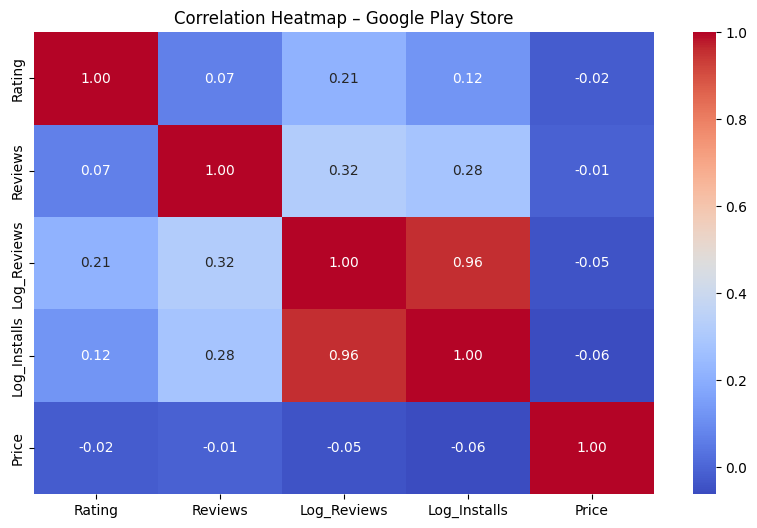

In [88]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap – Google Play Store")
plt.show()


In [90]:
category_rating=(
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)
category_rating.head(10)

Category
EVENTS                 4.435556
EDUCATION              4.389032
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.346067
PERSONALIZATION        4.335987
PARENTING              4.300000
GAME                   4.286326
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.277104
SHOPPING               4.259664
Name: Rating, dtype: float64

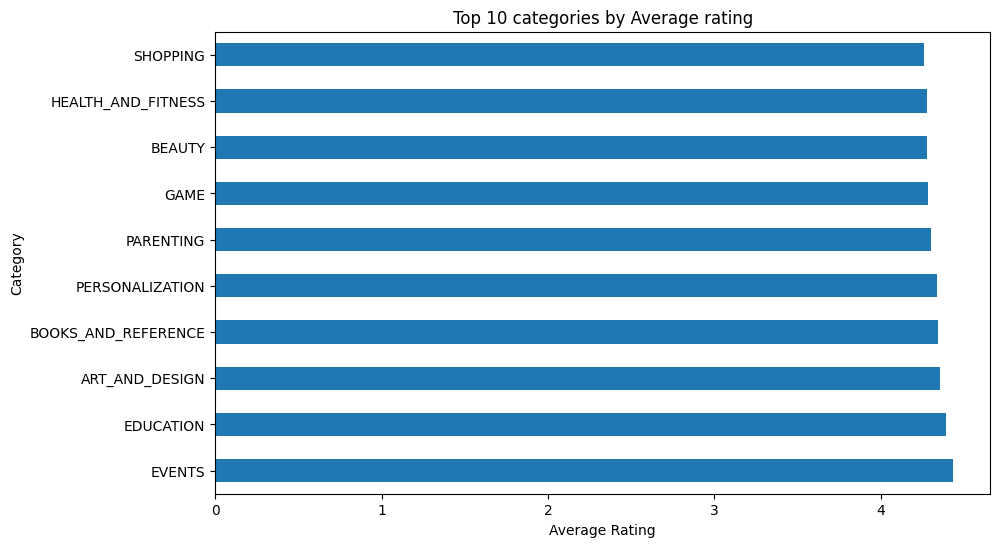

In [92]:
plt.figure(figsize=(10,6))
category_rating.head(10).plot(kind="barh")
plt.xlabel("Average Rating")
plt.title("Top 10 categories by Average rating")
plt.show()


Interpretation (WRITE THIS)


Niche categories such as Education, Events, and Books tend to have higher average ratings, possibly due to targeted user bases and lower competition.

In [94]:
category_installs=(
    df.groupby("Category")["Log_Installs"]
    .mean()
    .sort_values(ascending=False)
)
category_installs.head(10)

Category
ENTERTAINMENT     14.988010
GAME              14.200071
PHOTOGRAPHY       14.183573
COMMUNICATION     13.923031
EDUCATION         13.895106
SHOPPING          13.887320
WEATHER           13.510893
SOCIAL            13.469060
VIDEO_PLAYERS     13.305569
HOUSE_AND_HOME    13.208977
Name: Log_Installs, dtype: float64

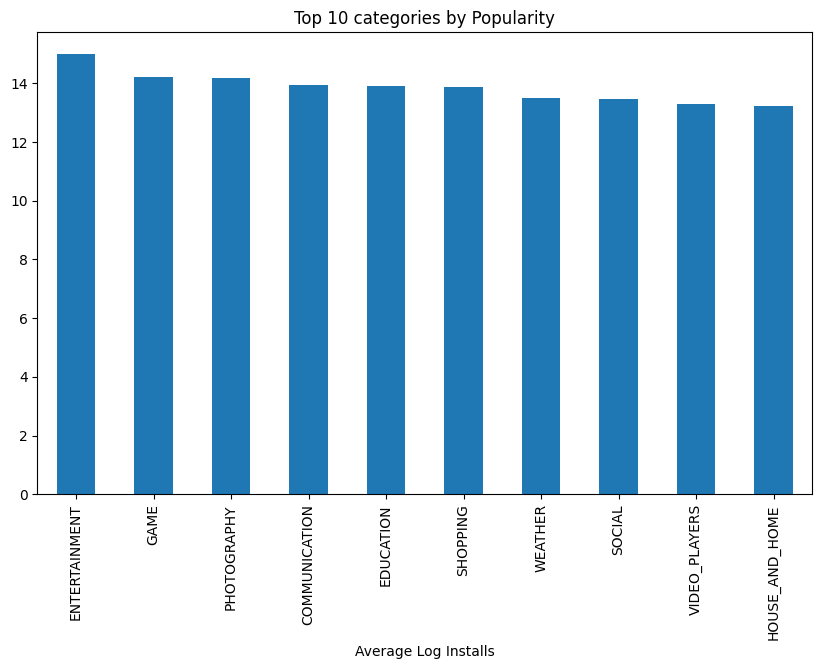

In [95]:
plt.figure(figsize=(10,6))
category_installs.head(10).plot(kind="bar")
plt.xlabel("Average Log Installs")
plt.title("Top 10 categories by Popularity")
plt.show()

🧠 Interpretation


Categories like Games, Communication, and Social dominate in installs, indicating mass adoption rather than niche usage.

In [99]:
category_summary=df.groupby("Category").agg(
    avg_rating=("Rating","mean"),
    avg_log_installs=("Log_Installs","mean"),
    app_count=("App","count")
).sort_values("avg_log_installs",ascending=False)
category_summary.head()

,avg_rating,avg_log_installs,app_count
Category,,,
ENTERTAINMENT,4.126174,14.988010,149
GAME,4.286326,14.200071,1097
PHOTOGRAPHY,4.192114,14.183573,317
COMMUNICATION,4.158537,13.923031,328
EDUCATION,4.389032,13.895106,155


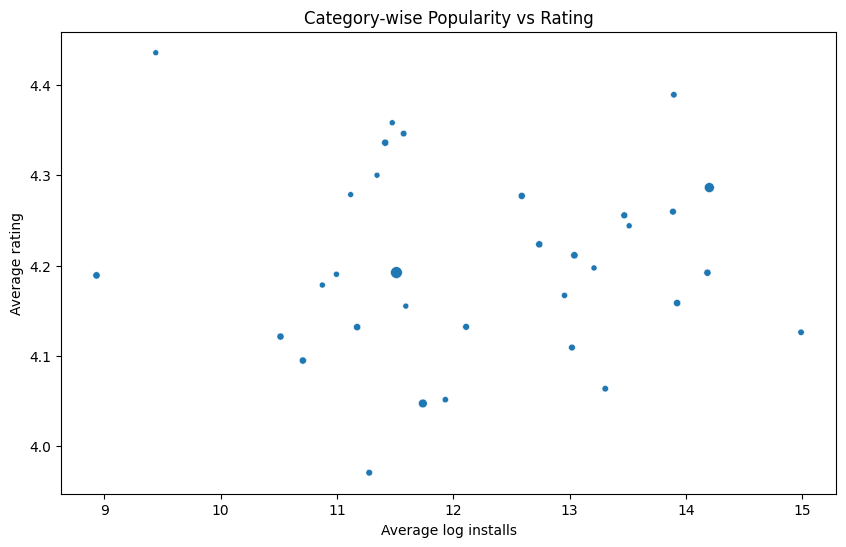

In [100]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="avg_log_installs",
    y="avg_rating",
    size="app_count",
    data=category_summary,
    legend=False
)
plt.xlabel("Average log installs")
plt.ylabel("Average rating")
plt.title("Category-wise Popularity vs Rating")
plt.show()